<a href="https://colab.research.google.com/github/aluongleekalierleek/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


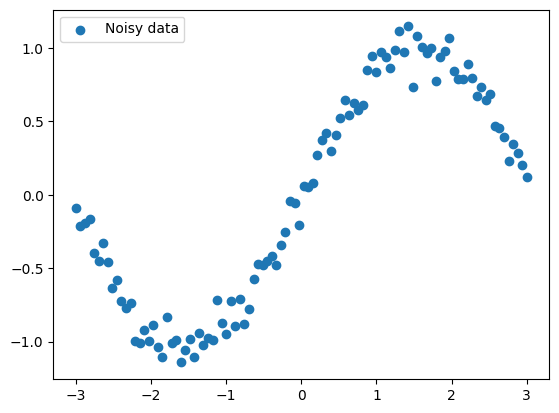

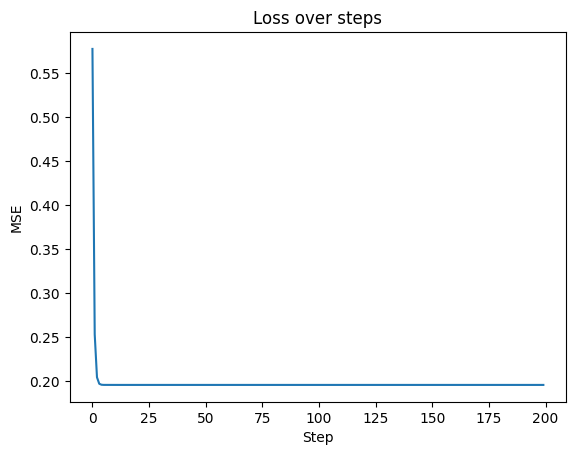

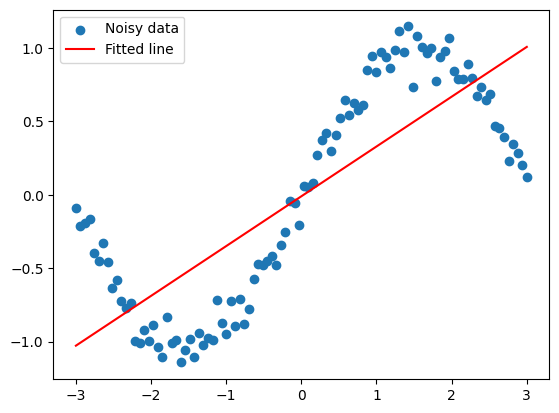

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # sine + Gaussian noise

plt.scatter(x, y, label="Noisy data")
plt.legend()
plt.show()

# 2. Initialize parameters
w = np.random.randn() * 0.01   # small random weight
b = np.random.randn() * 0.01   # small random bias
lr = 0.1                       # learning rate

# 3. Gradient descent loop
losses = []
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)   # dLoss/dw
    db = np.mean(2 * (y_hat - y))       # dLoss/db

    # Update
    w -= lr * dw
    b -= lr * db

# 4. Plot results
# (a) Loss curve
plt.plot(losses)
plt.title("Loss over steps")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# (b) Data with fitted line
plt.scatter(x, y, label="Noisy data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.legend()
plt.show()


**my reasoning: The single neuron**

1. Gradient:  
Loss = mean((y_hat - y)^2).  
So dLoss/dw = mean(2 * (y_hat - y) * x).  
And dLoss/db = mean(2 * (y_hat - y)).  
This is the same as in my code.

2. Fit:  
The loss goes down, but the line does not match the sine curve.  
This is underfitting because one straight line cannot follow the wave.  
A single neuron is only linear, so it can never learn sine.  
We need more layers and nonlinear functions to fit curves.




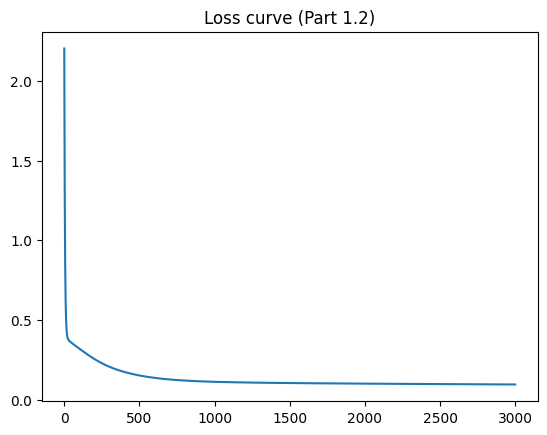

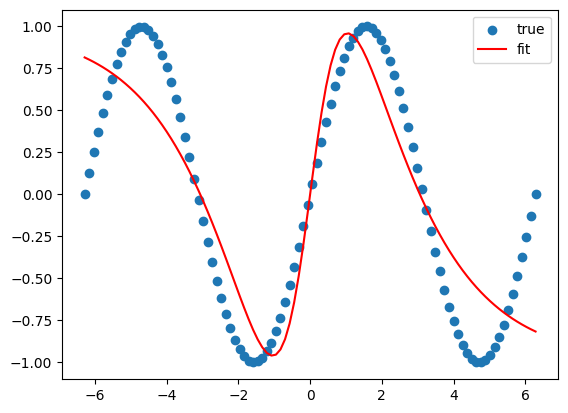

In [17]:
##part 1.2
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(-2*np.pi, 2*np.pi, 100).reshape(-1,1)
y = np.sin(x)

# Parameters
np.random.seed(0)
W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []

# Training loop
for step in range(3000):
    # Forward
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y)**2)
    losses.append(loss)

    # Backward
    d_yhat = 2*(y_hat - y)/len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1)**2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

# Plot loss
plt.plot(losses)
plt.title("Loss curve (Part 1.2)")
plt.show()

# Plot fit
plt.scatter(x,y,label="true")
plt.plot(x,y_hat,label="fit",color="red")
plt.legend()
plt.show()


**My Reasoning: Depth and activations**

1. If we remove tanh, the network is only linear on top of linear. A chain of linear layers is still just one line. That is why the fit looks the same as Part 1.1.

2. With tanh, the hidden layer makes curved features. Each of the 8 neurons learns a different curve. When we add them together, they can follow the sine wave much better.

3. Backpropagation is the chain rule used step by step to find gradients for all layers.


/tmp/ipykernel_2725/2726392269.py:22: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y)**2)
/tmp/ipykernel_2725/2726392269.py:29: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_2725/2726392269.py:30: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1)**2)


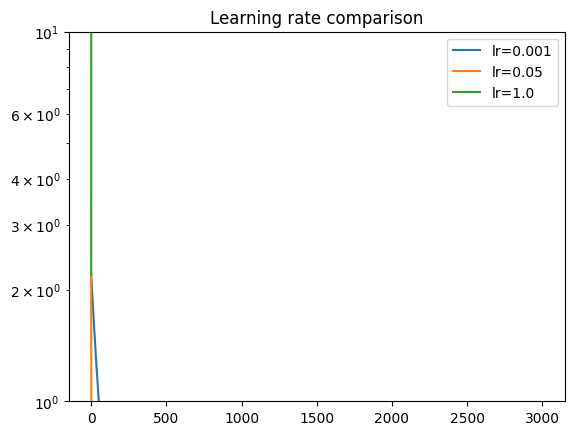

In [20]:
##part 1.3
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(-2*np.pi, 2*np.pi, 100).reshape(-1,1)
y = np.sin(x)

def train_toy(lr, steps=3000):
    np.random.seed(0)  # reset seed for fair comparison
    W1 = np.random.randn(1,8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8,1) * 0.5
    b2 = np.zeros(1)
    losses = []

    for step in range(steps):
        # Forward
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y)**2)
        losses.append(loss)

        # Backward
        d_yhat = 2*(y_hat - y)/len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1)**2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)

        # Update
        W1 -= lr*dW1
        b1 -= lr*db1
        W2 -= lr*dW2
        b2 -= lr*db2

    return losses

# Run with three learning rates
losses_small = train_toy(0.001)
losses_good  = train_toy(0.05)
losses_big   = train_toy(1.0)

# Plot
plt.plot(losses_small, label="lr=0.001")
plt.plot(losses_good, label="lr=0.05")
plt.plot(losses_big, label="lr=1.0")
plt.yscale("log")
plt.legend()
plt.title("Learning rate comparison")
plt.show()


**My Reasoning:Learning rate**

Here "lr" means learning rate.

- lr = 0.001: The curve goes down very slowly. Training is too cold, almost stuck.  
- lr = 0.05: The curve goes down smoothly. This is just right.  
- lr = 1.0: The curve jumps up and down. Loss explodes or oscillates. Too hot.  

A too-large learning rate does not mean faster learning. It overshoots the minimum, so the loss cannot settle.


In [26]:
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

RANDOM_STATE = 42
# Use the same OBESITY_URL as Lab 2
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

# Load dataset
df = pd.read_csv(OBESITY_URL)

# Encode categoricals (same choices as Lab 2)
df_encoded = df.copy()
df_encoded["Gender"] = df_encoded["Gender"].map({"Male":0, "Female":1})
df_encoded["family_history_with_overweight"] = df_encoded["family_history_with_overweight"].map({"no":0,"yes":1})
df_encoded["FAVC"] = df_encoded["FAVC"].map({"no":0,"yes":1})
df_encoded["SMOKE"] = df_encoded["SMOKE"].map({"no":0,"yes":1})
df_encoded["SCC"] = df_encoded["SCC"].map({"no":0,"yes":1})
df_encoded["MTRANS"] = df_encoded["MTRANS"].astype("category").cat.codes
df_encoded["CAEC"] = df_encoded["CAEC"].astype("category").cat.codes
df_encoded["CALC"] = df_encoded["CALC"].astype("category").cat.codes

# Target encoding
le = LabelEncoder()
y = le.fit_transform(df_encoded["NObeyesdad"])
X = df_encoded.drop("NObeyesdad", axis=1).values

# Stratified split 60/20/20
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

# Scale (fit only on training set)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Convert to tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

# Wrap in DataLoaders
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)


**My Reasoning: Preprocessing for neural networks**

1. CrossEntropyLoss wants class labels as numbers (like 0, 1, 2 … 6). It does the softmax and loss calculation inside. If we gave one‑hot vectors, it would not work the way PyTorch expects.

2. Random forests don’t care about feature scale because they just split data at certain values. Neural networks do care because the math for gradients uses the size of the inputs. If inputs are too big or too small, the updates can blow up or shrink to nothing.

3. `shuffle=True` makes the training data come in a different order each time. This stops the model from learning the order of the data and helps it learn the patterns better.


In [28]:
##part2.2
import torch
import torch.nn as nn

# Define FeedForwardNet
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)   # raw logits, no softmax
        return x

# Instantiate model
input_dim = X_train.shape[1]   # number of features
model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)

# Move to device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

# Print model
print(model)

# Count trainable parameters
param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", param_count)

# Verify first layer count by hand
print("First layer params (manual):", input_dim * 64 + 64)


FeedForwardNet(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 3399
First layer params (manual): 1088


**My Reasoning: Architecture**

1. First layer has input_dim × 64 weights plus 64 biases.  
   Second layer has 64 × 32 weights plus 32 biases.  
   Output layer has 32 × 7 weights plus 7 biases.  
   Adding them gives the same total as PyTorch shows.

2. ReLU is better than tanh here because it is faster and avoids the problem of very small gradients. This makes training easier.

3. If we removed the ReLUs, the network would just be one big linear function. That means it could not learn complex patterns, only straight lines.
